In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load dataset
df = pd.read_csv('AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
## Explore dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
## Check for missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
## Check number of rows and columns of dataset
df.shape

(6362620, 11)

## Exploratory Data Analysis

### Overall distribution

In [6]:
## Finding the distribution of transaction types (values)
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

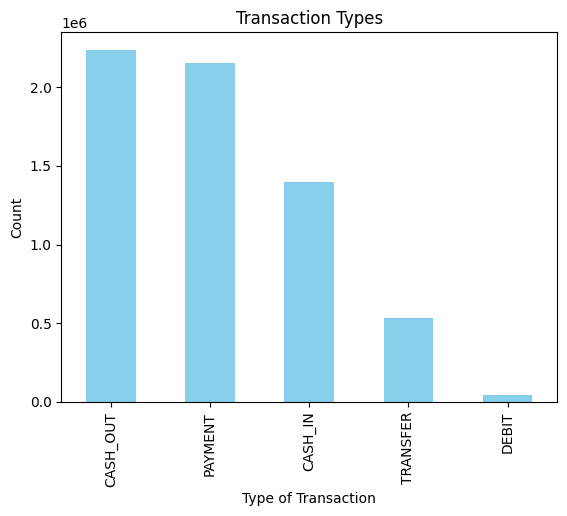

In [7]:
## Finding the distribution of transaction types (plot)
df['type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Transaction Types')
plt.xlabel('Type of Transaction')
plt.ylabel('Count')
plt.show()

In [8]:
## Finding out distribution of fraudulent vs non-fraudulent transactions (values)
fraud_counts = df['isFraud'].value_counts()
fraud_counts

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
## Finding out distribution of fraudulent vs non-fraudulent transactions (percentages)
fraud_percentages = df['isFraud'].value_counts(normalize=True) * 100
fraud_percentages

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

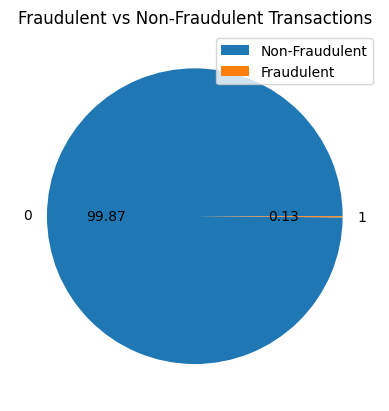

In [10]:
## Finding out distribution of fraudulent vs non-fraudulent transactions (plot)
fraud_percentages.plot(kind='pie', color=['orange', 'green'], autopct='%.2f')
plt.title('Fraudulent vs Non-Fraudulent Transactions')
plt.ylabel('')
plt.legend(labels=['Non-Fraudulent', 'Fraudulent'], loc='upper right')
plt.show()

In [11]:
## Finding out distribution of fraudulent vs non-fraudulent transaction types (values)
fraud_type_distribution = df.groupby('type')['isFraud'].value_counts().unstack().fillna(0)
fraud_type_distribution

isFraud,0,1
type,,
CASH_IN,1399284.0,0.0
CASH_OUT,2233384.0,4116.0
DEBIT,41432.0,0.0
PAYMENT,2151495.0,0.0
TRANSFER,528812.0,4097.0


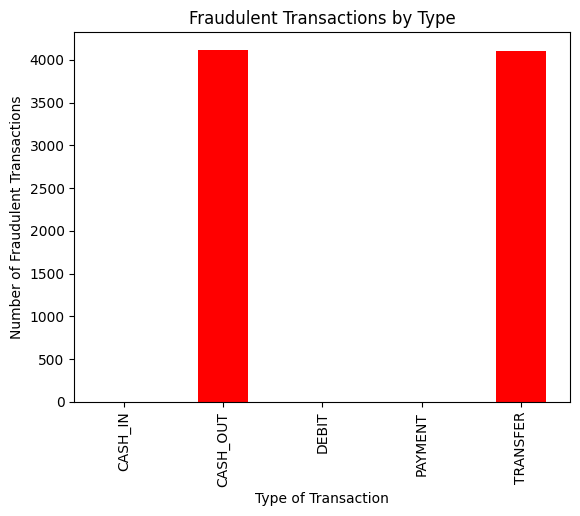

In [12]:
## Finding out distribution of fraudulent vs non-fraudulent transaction types (plot)
isFraud_type = df.groupby('type')['isFraud'].sum()
isFraud_type.plot(kind='bar', color='red')
plt.title('Fraudulent Transactions by Type')
plt.xlabel('Type of Transaction')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

### Temporal trends

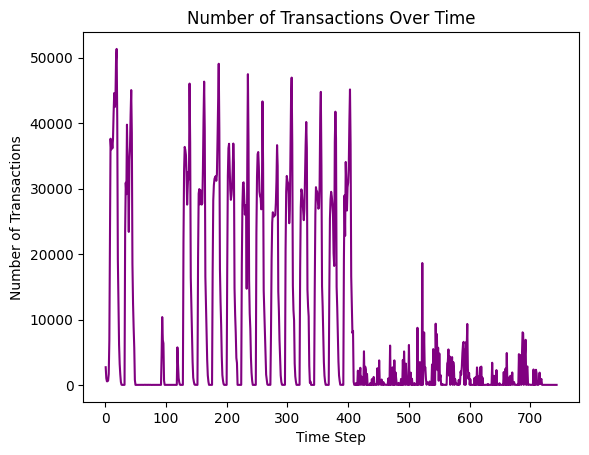

In [13]:
## Finding the distribution of total number of transactions over time (plot)
df['step'].value_counts().sort_index().plot(kind='line', color='purple')
plt.title('Number of Transactions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Transactions')
plt.show()

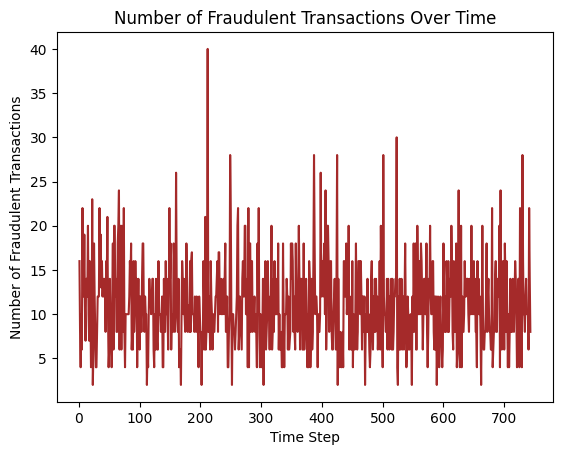

In [14]:
## Finding the distribution of number of fraudulent transactions over time (plot)
df[df['isFraud'] == 1]['step'].value_counts().sort_index().plot(kind='line', color='brown')
plt.title('Number of Fraudulent Transactions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.show() 

Total number of transactions were much higher when time step is less than 400 hours, and drastically dropped afterwards. Number of fraudulent transactions remained roughly constant throughout the time step, with occasional spikes. 
This shows that, despite the number of transactions, number of fraudulent transactions tend to be persistent and happens at a steady rate

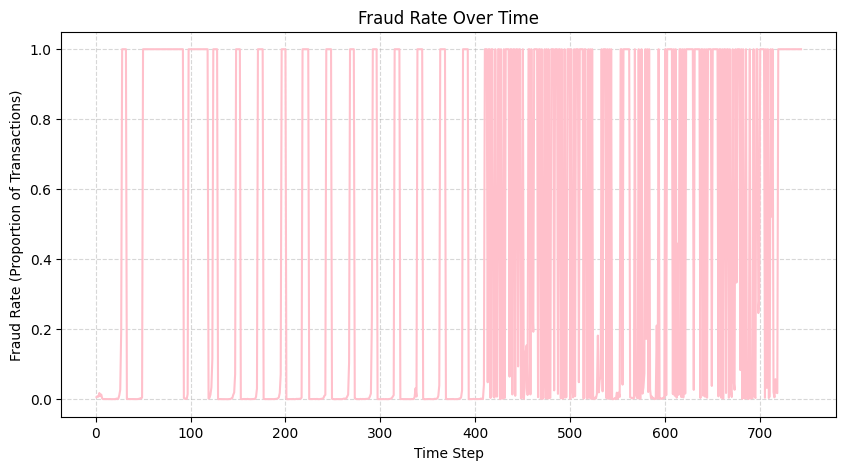

In [15]:
# Compute fraud rate per step
fraud_rate = df.groupby('step')['isFraud'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(fraud_rate['step'], fraud_rate['isFraud'], color='pink')
plt.title('Fraud Rate Over Time')
plt.xlabel('Time Step')
plt.ylabel('Fraud Rate (Proportion of Transactions)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

By plotting the fraud rate over time, we can see that number of fraudulent transactions are more noticable when the total volume of transactions is much lower after 400 hours

### Monetary behaviour

In [16]:
## Finding the distribution of transaction amounts by fraud status (values)
isFraud_by_amount = df.groupby('isFraud')['amount'].describe()
isFraud_by_amount

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


/var/folders/jg/17fvjb1x4y3dr0br_h6n915r0000gn/T/ipykernel_52832/345446949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')


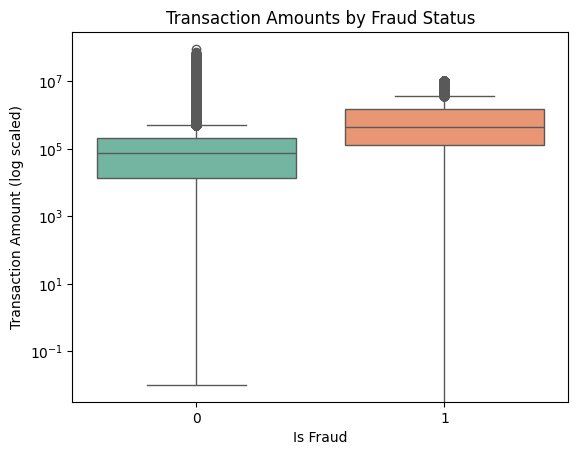

In [17]:
## Finding the distribution of transaction amounts by fraud status (plot)
sns.boxplot(x='isFraud', y='amount', data=df, palette='Set2')
plt.title('Transaction Amounts by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount (log scaled)')
plt.yscale('log')  # Use logarithmic scale for better visualization
plt.show()

Typically, when transaction amounts are higher, it is more likely to be a fraudulent transaction, although there might be outliers. 

### Account balance patterns

/var/folders/jg/17fvjb1x4y3dr0br_h6n915r0000gn/T/ipykernel_52832/253321574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='diffBalanceOrig', data=df, palette='Set3')


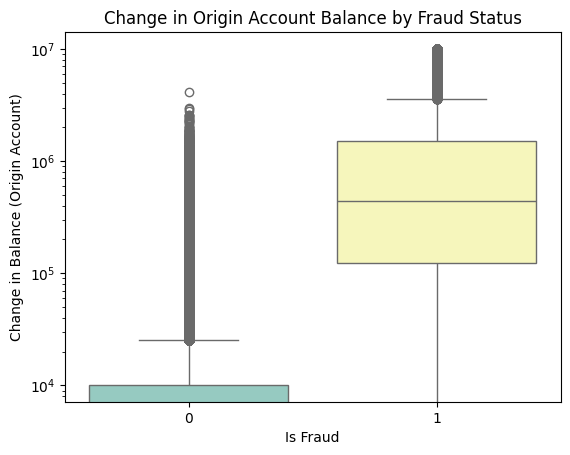

In [18]:
## Finding distribution of source account balances by fraud status (plot)
df['diffBalanceOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
sns.boxplot(x='isFraud', y='diffBalanceOrig', data=df, palette='Set3')
plt.title('Change in Origin Account Balance by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Change in Balance (Origin Account)')
plt.yscale('log')  # Use logarithmic scale for better visualization
plt.show()

In [32]:
df.groupby('isFraud')['diffBalanceOrig'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-2.314152e+04,1.062233e+05,-1915267.9,0.00,0.00,10102.125,4164236.31
1,8213.0,1.457275e+06,2.396099e+06,0.0,124582.58,436317.49,1503034.860,10000000.00


Fraudulent transactions tend to involve higher changes in balance of source accounts

/var/folders/jg/17fvjb1x4y3dr0br_h6n915r0000gn/T/ipykernel_52832/3485130571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='diffBalanceDest', data=df, palette='Set3')


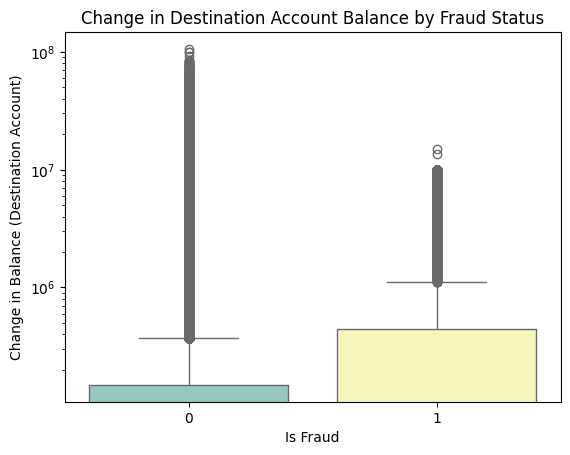

In [20]:
## Finding distribution of destination account balances by fraud status (plot)
df['diffBalanceDest'] = df['newbalanceDest'] - df['oldbalanceDest']
sns.boxplot(x='isFraud', y='diffBalanceDest', data=df, palette='Set3')
plt.title('Change in Destination Account Balance by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Change in Balance (Destination Account)')
plt.yscale('log')  # Use logarithmic scale for better visualization
plt.show()

### Correlations

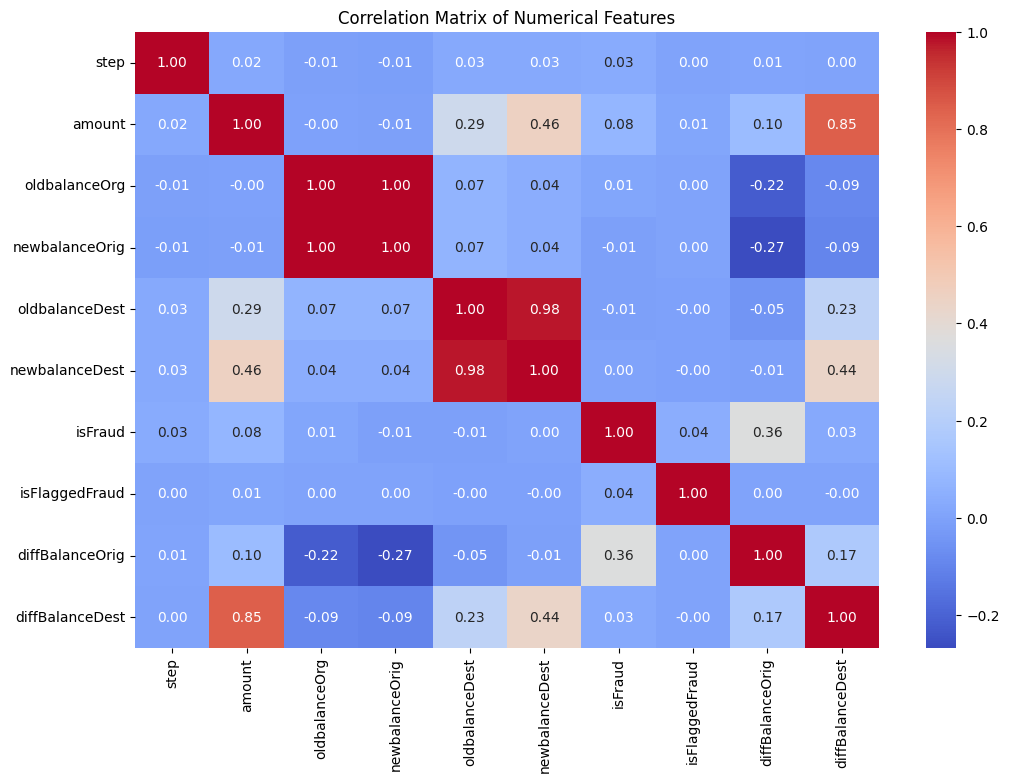

In [21]:
## creating heatmap to show correlations between numerical features
plt.figure(figsize=(12,8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The factor with the highest correlation with whether a transaction is fraudulent or not is would be 'diffBalanceOrig', which is the different in balance in the source account

## Model prediction

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [23]:
y = df['isFraud']
X = df.drop(columns=['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)  # Drop non-numeric and target columns
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,diffBalanceOrig,diffBalanceDest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,181.00,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0


In [24]:
## split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

Training set size: 5090096 samples
Testing set size: 1272524 samples


In [25]:
## Splitting categorical and numerical variables
categorical = ['type']
numerical = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'diffBalanceOrig', 'diffBalanceDest', 'step']

In [26]:
## preprocessing and creating pipelines for both numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [27]:
## Fitting the pipeline with training data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'diffBalanceOrig',
                                                   'diffBalanceDest', 'step']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [28]:
## Predicting fraud cases using the model with testing data
y_pred = pipeline.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.96      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [30]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1206920   63961]
 [     64    1579]]


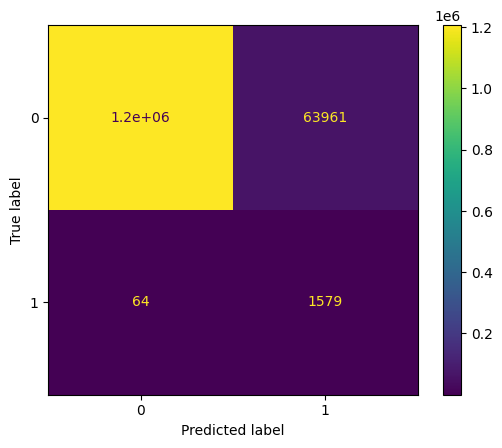

In [31]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)

From the classification report, while the recall and f1-score is very high, precision rate is very low. This means that the model is flagging too many normal transactions as fraud. This is likely due to the highly imbalanced dataset, where only 0.12% of the dataset was fraud transactions. Thus, the logistic regression model may not be the best for this case scenario